In [1]:
%run "./crop.ipynb"
import os
import torch
from model import model_final as model,device
from dataset import test_transform as transform
from torch.amp import autocast 
import torch.nn.functional as F


Genuine authors : 268
Forgery authors : 276
  Author 001: 24 genuine signatures
  Author 002: 24 genuine signatures
  Author 003: 24 genuine signatures
  Author 004: 24 genuine signatures
  Author 006: 24 genuine signatures
  Author 009: 24 genuine signatures
  Author 012: 24 genuine signatures
  Author 014: 24 genuine signatures
  Author 015: 24 genuine signatures
  Author 016: 23 genuine signatures
  Author 021: 24 genuine signatures
  Author 022: 24 genuine signatures
  Author 023: 24 genuine signatures
  Author 024: 24 genuine signatures
  Author 025: 24 genuine signatures
  Author 026: 24 genuine signatures
  Author 027: 24 genuine signatures
  Author 028: 24 genuine signatures
  Author 029: 24 genuine signatures
  Author 036: 24 genuine signatures
  Author 037: 24 genuine signatures
  Author 038: 24 genuine signatures
  Author 039: 24 genuine signatures
  Author 040: 24 genuine signatures
  Author 041: 24 genuine signatures
  Author 042: 24 genuine signatures
  Author 043: 24 gen

In [2]:
base_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test"
input_path = os.path.join(base_path,"input")
for filename in os.listdir(input_path):
    input_files=os.path.join(input_path,filename)
    output_dir=os.path.join(base_path,"input_processed")
    os.makedirs(output_dir, exist_ok=True)
    output_files = os.path.join(output_dir, filename.split('.')[0] + ".PNG")
    crop_and_save_signature(input_files,output_files)

In [10]:
img_ref_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test\input_processed\ref_02.PNG"
img_query_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test\input_processed\fake_02.PNG"
img_ref = Image.open(img_ref_path).convert('L')
img_query =Image.open(img_query_path).convert('L')
img_ref = transform(img_ref)
img_query = transform(img_query)

In [11]:
margin = 1.2
lr = 0.001
# best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"
# best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_focal_dynamic_margin{margin}_lr{lr}.pt"
# best_model_path='best_model_optimized.pt'
def unwrap(m):
    if hasattr(m, '_orig_mod'): return m._orig_mod
    if hasattr(m, 'module'):    return m.module
    return m

# Always load into the raw (unwrapped) model
model = unwrap(model).to(device)

In [12]:
best_model_path = 'checkpoints/best_model.pt'
ckpt = torch.load(best_model_path, map_location=device, weights_only=False)

model.load_state_dict(ckpt["model_state"])
model.eval()

# Use the threshold the model found during validation (or override manually)
threshold = ckpt.get("threshold", 0.372)
print(f"Loaded checkpoint  |  threshold={threshold:.4f}")



Loaded checkpoint  |  threshold=0.4364


In [13]:

with torch.no_grad():
        img1 = img_ref.unsqueeze(0).to(device, non_blocking=True)
        img2 = img_query.unsqueeze(0).to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        result = "Genuine" if distance < threshold else "Forgery"
        print(result,distance)

Genuine tensor([0.3359], device='cuda:0')


C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


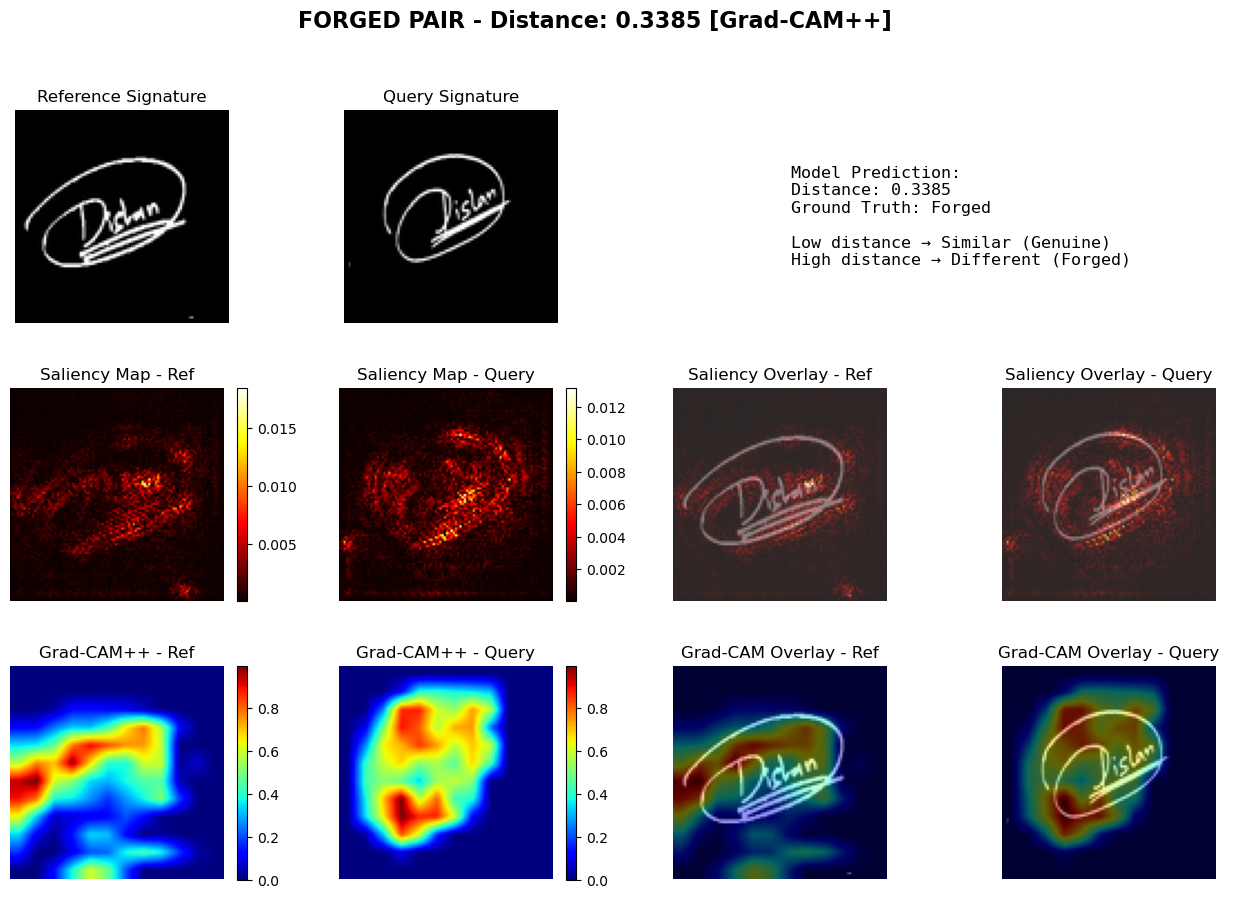

In [14]:
from saliency_visualization import SaliencyVisualizer, analyze_model_focus
visualizer = SaliencyVisualizer(model, device)

visualizer.visualize_pair(
    img1, 
    img2, 
    0)